# Tracking the Growth of Artificial Intelligence Research, 2000–2025
### DATASCI 530 · Assignment 3 · Whitney Barr
# Data source: OpenAlex Works API (https://docs.openalex.org)

## Summary of Findings
 **Size of the field** Over **300,000** works in OpenAlex have "artificial intelligence" in their title.
- **Who publishes** Since 2000, **the US** leads AI publishing, followed by **China** and **India**.
- **Most cited** The most cited AI paper since 2000 is **"High-performance medicine: the convergence of human and artificial intelligence"** (2018), with **10,279** citations.
- **Growth** AI-title matches rose from **303** in 2000 to **77,047** in 2025. LLM and GPT title matches increased sharply beginning in 2023.
- **New insight** **The United States leads in AI papers per year for most of this time period, while China briefly moves ahead around 2010 and nearly catches up again by 2025. Counts for all four countries rise sharply after 2020.**

## Methodology
- **Data access.** I use the OpenAlex **Works API**. The API returns **JSON**, so no web crawling (Selenium) is needed. I send requests with `requests` and navigate the JSON with `jmespath`.
- **Search definition.** A work counts as "about AI" when its **title** contains the exact phrase "artificial intelligence". I use the `title.search` filter with the phrase in quotes. Searching titles (not full text) is stricter, but it keeps the sample focused on papers *about* AI.
- **Counting.** The API returns 25 records per page by default. To count everything, I read `meta.count`, or I use `group_by`, which counts **all** matching records on the server.
- **Time window.** "Since 2000" = publication years 2000 onward. For year-to-year trends I stop at **2025**, because 2026 is still in progress.
- **Automation.** I use `for` loops to repeat the same API call for several keywords and countries.



In [189]:
## Setup
#import packages

import requests      # Requests data from an API
import json          # Handles JSON object
import pandas as pd  # Handles data frames
import jmespath      # Navigates nested JSON
import matplotlib.pyplot as plt  # Makes graphs

BASE_URL = "https://api.openalex.org/works"

# The search phrase used throughout the notebook
AI_FILTER = 'title.search:"artificial intelligence"'

## 1. How many works have "artificial intelligence" in their titles?

**Approach.** I filter on titles only and read the total from `meta.count`. This is the total number of matching records, not just the 25 shown on the first page.


In [190]:

# Base address of the OpenAlex Works API
BASE_URL = "https://api.openalex.org/works"
# Define the URL to the OpenAlex API
title_params = {
    "filter": 'title.search:"artificial intelligence"', 
     "per-page": 1
}
# Request the data and convert the JSON
title_response = requests.get(BASE_URL, params=title_params)
title_response.raise_for_status()
title_data = title_response.json()       
#Take the OpenAlex JSON response, look under the meta object, and save the total match count into ai_title_count
ai_title_count = title_data["meta"]["count"]

print(f"Works with 'artificial intelligence' in the title: {ai_title_count:,}")

Works with 'artificial intelligence' in the title: 333,848


## 2. AI publications since 2000, by country of the authors' affiliations

**Approach.**
- I add a second filter, `publication_year:>1999`, so only works from 2000 onward count.
- `group_by=authorships.countries` asks OpenAlex to count works **for each country** of the authors' institutions.
- `per_page=200` makes sure every country comes back in one reply.

**Important note on counting.** A paper with authors from the US *and* China counts once for **each** country. So the country totals add up to **more** than the number of papers. That is expected, not an error.

In [191]:
# Build the API URL
# Filter: titles matching "artificial intelligence"
# publication_year:>1999 keeps only 2000 onward
# group_by=authorships.countries counts by country of authors' affiliations

url_q2 = (
    BASE_URL
    + "?filter=" + AI_FILTER + ",publication_year:>1999"
    + "&group_by=authorships.countries"
    + "&per_page=200"
)

# Request the data and convert the JSON
q2_results = requests.get(url_q2).json()

# Convert the grouped results into a DataFrame
q2_df = pd.DataFrame(q2_results["group_by"])

# Extract the country code from the URL
q2_df["country_code"] = q2_df["key"].str.split("/").str[-1]

# Rename columns to readable names
q2_df = q2_df.rename(columns={
    "key_display_name": "Country",
    "count": "AI publications"
})

# Sort from most to fewest and display results
q2_df = q2_df.sort_values("AI publications", ascending=False).reset_index(drop=True)

# Clean up the output using the same .style.format() method from lecture 3d
(q2_df
    .style
    .format({"AI publications": "{:,}"})
    .set_caption("AI publications by country, 2000–present"))

,key,Country,AI publications,country_code
0,https://openalex.org/countries/US,United States,"37,241",US
1,https://openalex.org/countries/CN,China,"30,124",CN
2,https://openalex.org/countries/IN,India,"25,011",IN
3,https://openalex.org/countries/GB,United Kingdom,"12,734",GB
4,https://openalex.org/countries/ID,Indonesia,"9,434",ID
5,https://openalex.org/countries/IT,Italy,"7,470",IT
6,https://openalex.org/countries/DE,Germany,"6,925",DE
7,https://openalex.org/countries/TR,Turkey,"6,718",TR
8,https://openalex.org/countries/RU,Russia,"5,968",RU
9,https://openalex.org/countries/CA,Canada,"5,915",CA


In [192]:
q2_total_works = q2_results["meta"]["count"]
print(f"AI works published since 2000: {q2_total_works:,}")
print(f"Number of country groups returned: {len(q2_df)}")

AI works published since 2000: 324,957
Number of country groups returned: 200


**Table 1. Top 15 countries by number of AI publications, 2000–present**

*Counts are by the country of authors' institutions. Papers with authors from several countries count once per country.* The full table has every country; I show the top 15 to keep it readable.

In [193]:
# Keep the top 15 countries and their country codes from Question 2
q2_countries = q2_df[["Country", "AI publications", "country_code"]].copy()
table_q2 = q2_countries[["Country", "AI publications"]].head(15).copy()
table_q2.index = range(1, len(table_q2) + 1)
table_q2.index.name = "Rank"

# Clean up the table display
(table_q2
    .style
    .format({"AI publications": "{:,}"})
    .set_caption("Top 15 countries by AI publications, 2000–present"))

,Country,AI publications
Rank,,
1,United States,"37,241"
2,China,"30,124"
3,India,"25,011"
4,United Kingdom,"12,734"
5,Indonesia,"9,434"
6,Italy,"7,470"
7,Germany,"6,925"
8,Turkey,"6,718"
9,Russia,"5,968"


## 3. The 10 most cited AI papers since 2000

**Approach.**
- Same filter as Question 2.
- `sort=cited_by_count:desc` puts the most cited papers first.
- `per_page=10` returns just the top 10.
- A `for` loop goes through each paper and pulls out the title, year, citations, authors and institutions.

**Cleaning choices.**
- Some papers have dozens of authors. To keep the table readable, I list the **first 3 authors** and add "et al." when there are more.
- An author can list several institutions, and several authors can share one. I keep each institution **once** (no duplicates).
- If no institution is recorded, I write "Not listed".

In [194]:
##3 
url_q3 = (BASE_URL
          + "?filter=" + AI_FILTER + ",publication_year:>1999"
          + "&sort=cited_by_count:desc"
          + "&per_page=10")

q3_results = requests.get(url_q3).json()
top_papers = q3_results["results"]

data_q3 = []
for i in range(len(top_papers)):
    paper = top_papers[i]

    author_names = jmespath.search("authorships[*].author.display_name", paper)
    num_authors = len(author_names)
    if num_authors > 3:
        authors_text = ", ".join(author_names[0:3]) + " et al."
    else:
        authors_text = ", ".join(author_names)

    institution_names = jmespath.search("authorships[].institutions[].display_name", paper)
    unique_institutions = []
    for name in institution_names:
        if name not in unique_institutions:
            unique_institutions.append(name)
    if len(unique_institutions) == 0:
        institutions_text = "Not listed"
    else:
        institutions_text = "; ".join(unique_institutions)

    data_q3.append({"Title": paper["display_name"],
                    "Year": paper["publication_year"],
                    "Citations": paper["cited_by_count"],
                    "Authors": authors_text,
                    "Num. authors": num_authors,
                    "Institutions": institutions_text})

q3_df = pd.DataFrame(data_q3)

In [195]:
#quality check

print(f"Papers returned: {len(q3_df)}")
print(f"Sorted by citations (high to low): {q3_df['Citations'].is_monotonic_decreasing}")
print(f"Papers with no institution listed: {(q3_df['Institutions'] == 'Not listed').sum()}")

Papers returned: 10
Sorted by citations (high to low): True
Papers with no institution listed: 1


**Table 2. The 10 most cited papers with "artificial intelligence" in the title, 2000–present**

In [196]:
table_q3 = q3_df.copy()
table_q3.index = range(1, len(table_q3) + 1)
table_q3.index.name = "Rank"
table_q3["Citations"] = table_q3["Citations"].map("{:,}".format)

# Wrap long text so the table fits on the page
(table_q3.style
    .set_properties(**{"text-align": "left", "white-space": "normal"})
    .set_properties(subset=["Title", "Institutions"], **{"max-width": "320px"}))

,Title,Year,Citations,Authors,Num. authors,Institutions
Rank,,,,,,
1,High-performance medicine: the convergence of human and artificial intelligence,2018,"10,279",Eric J. Topol,1,Scripps Research Institute
2,"Explainable Artificial Intelligence (XAI): Concepts, taxonomies, opportunities and challenges toward responsible AI",2019,"10,137","Alejandro Barredo Arrieta, Natalia Díaz-Rodríguez, Javier Del Ser et al.",12,Tecnalia; Institut national de recherche en sciences et technologies du numérique; École Nationale Supérieure de Techniques Avancées; École Nationale Supérieure de Techniques Avancées Paris; Unité d'Informatique et d'Ingénierie des Systèmes; Sorbonne Université; Institut Systèmes Intelligents et de Robotique; Universidad de Granada; Telefónica (Spain); Telefonica Research and Development
3,Systematic review of research on artificial intelligence applications in higher education – where are the educators?,2019,"6,847","Olaf Zawacki‐Richter, Victoria I. Marín, Melissa Bond et al.",4,Carl von Ossietzky Universität Oldenburg
4,Peeking Inside the Black-Box: A Survey on Explainable Artificial Intelligence (XAI),2018,"6,290","Amina Adadi, Mohammed Berrada",2,Sidi Mohamed Ben Abdellah University
5,Proceedings of the 19th International Joint Conference on Artificial Intelligence,2005,"5,781","Josep M. Pujol, Jordi Delgado, Ramón Sangüesa et al.",4,Not listed
6,Explanation in artificial intelligence: Insights from the social sciences,2018,"5,266",Tim Miller,1,The University of Melbourne
7,"Artificial intelligence in healthcare: past, present and future",2017,"4,901","Fei Jiang, Yong Jiang, Hui Zhi et al.",12,University of Hong Kong; Capital Medical University; Beijing Tian Tan Hospital; Fudan University; Huashan Hospital
8,"Artificial Intelligence (AI): Multidisciplinary perspectives on emerging challenges, opportunities, and agenda for research, practice and policy",2019,"4,526","Yogesh Kumar Dwivedi, Laurie Hughes, Elvira Ismagilova et al.",35,Prin. L. N. Welingkar Institute of Management Development and Research; Swansea University; University of Bradford; Loughborough University; University of Bedfordshire; Aston University; University of Edinburgh; Indian Institute of Technology Delhi; Delft University of Technology; Copenhagen Business School; University of East Anglia; Government of Tamil Nadu; University of Greenwich; Indian Institute of Management Tiruchirappalli; Symbiosis International University; University of Essex; University of the West of England; Capgemini (United Kingdom)
9,"BNAI, NO-TOKEN, and MIND-UNITY: Pillars of a Systemic Revolution in Artificial Intelligence",2022,"4,271","Wei, Jason, Wang, Xuezhi, Dale Schuurmans et al.",9,Google (United States)


## 4. Year-to-year change: "artificial intelligence" vs. "LLM", "GPT", and "machine learning"

**Approach.**
- I put the 4 search terms in a list and use a `for` loop to make the **same** API call for each one.
- `group_by=publication_year` returns one count per year.
- `publication_year:2000-2025` keeps only complete years.
- My extra keyword is **"machine learning"**, the closest related field to AI. 

In [197]:
# Search terms: label shown on the graph -> phrase sent to the API
keywords = {"Artificial intelligence": "artificial intelligence",
            "Machine learning"       : "machine learning",
            "LLM"                    : "LLM",
            "GPT"                    : "GPT"}

# Store one list of yearly counts for each search term
data_q4 = {}
for label in keywords:
    phrase = keywords[label]
    url_q4 = (BASE_URL
              + '?filter=title.search:"' + phrase + '",publication_year:2000-2025'
              + "&group_by=publication_year"
              + "&per_page=200")

    q4_results = requests.get(url_q4).json()

# Add a count for each year; start at 0 for years missing from the API results
    year_counts = []
    for year in range(2000, 2026):
        year_count = 0
        for group in q4_results["group_by"]:
            if int(group["key"]) == year:
                year_count = group["count"]
        year_counts.append(year_count)

    data_q4[label] = year_counts

# Make a table with years as the index and search terms as columns
q4_wide = pd.DataFrame(data_q4)
q4_wide.index = range(2000, 2026)

In [198]:
# Check the years included in the table
print("Years covered:", q4_wide.index[0], "to", q4_wide.index[-1])
print("Number of years:", len(q4_wide))
print()

# Print the total papers for each search term
for term in keywords:
    print(term, ":", q4_wide[term].sum())

print()
print("AI total from Question 2 (2000-present):", q2_total_works)

Years covered: 2000 to 2025
Number of years: 26

Artificial intelligence : 231605
Machine learning : 430488
LLM : 41268
GPT : 8162

AI total from Question 2 (2000-present): 324957


**Figure 1.** Both panels use linear y-axes. The upper panel compares "artificial intelligence" and "machine learning"; the lower panel compares "LLM" and "GPT". Each panel has its own scale, so compare year-to-year patterns within a panel, not count heights across panels.

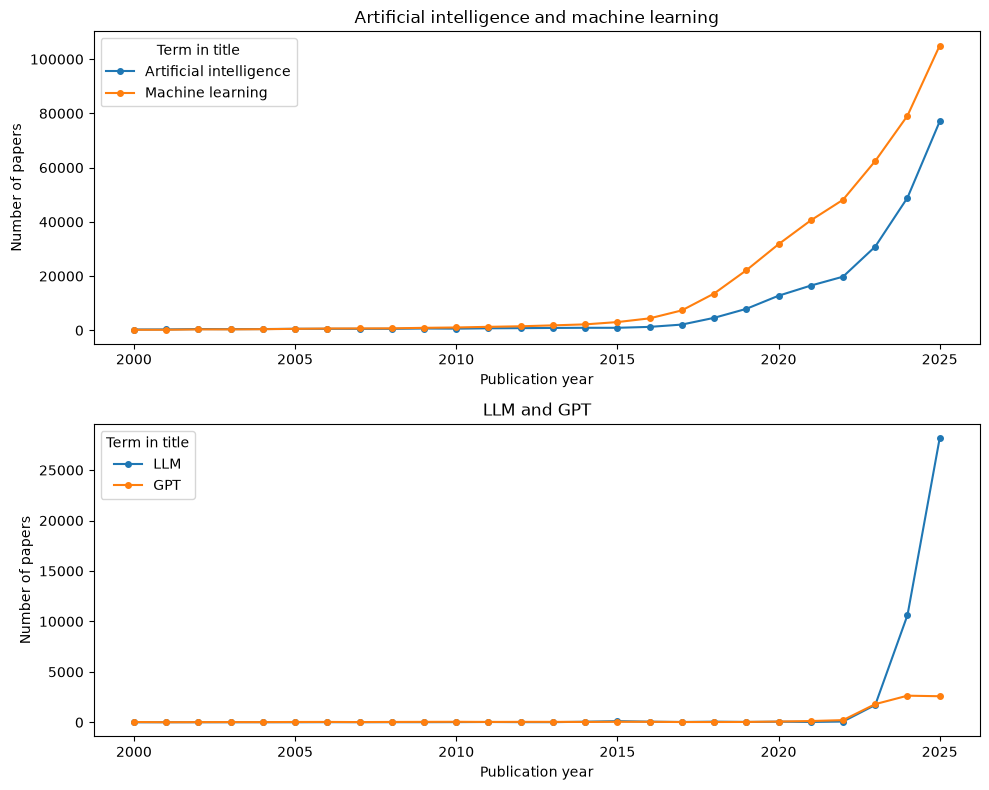

In [199]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

q4_wide[["Artificial intelligence", "Machine learning"]].plot(
    kind="line", marker="o", markersize=4, ax=axes[0])
axes[0].set_title("Artificial intelligence and machine learning")
axes[0].set_xlabel("Publication year")
axes[0].set_ylabel("Number of papers")
axes[0].legend(title="Term in title")

q4_wide[["LLM", "GPT"]].plot(
    kind="line", marker="o", markersize=4, ax=axes[1])
axes[1].set_title("LLM and GPT")
axes[1].set_xlabel("Publication year")
axes[1].set_ylabel("Number of papers")
axes[1].legend(title="Term in title")

plt.tight_layout()
plt.savefig("fig1_keyword_trends.png", dpi=200)
plt.show()

**Table 3. Papers per year, selected years**

In [200]:
selected_years = [2000, 2005, 2010, 2015, 2020, 2022, 2023, 2024, 2025]
table_q4 = q4_wide.loc[selected_years].copy()
table_q4.index.name = "Year"

# Format the counts and add a caption, following Lecture 3d
(table_q4.style
    .format({"Artificial intelligence": "{:,}",
             "Machine learning": "{:,}",
             "LLM": "{:,}",
             "GPT": "{:,}"})
    .set_caption("Papers by title keyword, selected years"))

,Artificial intelligence,Machine learning,LLM,GPT
Year,,,,
2000,303,199,4,31
2005,565,547,9,34
2010,617,"1,049",21,52
2015,930,"3,040",117,54
2020,"12,760","31,756",63,77
2022,"19,782","48,148",77,218
2023,"30,880","62,445","1,719","1,804"
2024,"48,909","79,151","10,624","2,640"
2025,"77,047","105,023","28,175","2,586"


**Interpretation.**

The number of works with "artificial intelligence" in the title rose from 303 in 2000 to 77,047 in 2025, about 254 times as many. Growth was gradual through 2015, then sped up: the count rose from 930 in 2015 to 12,760 in 2020, and continued increasing through 2025.

LLM and GPT title counts were still low in 2022, then both increased sharply in 2023, after ChatGPT launched in late 2022. LLM grew from 77 papers in 2022 to 28,175 in 2025. GPT rose from 218 to 2,586 over the same period, after peaking at 2,640 in 2024.

Machine learning became more common than artificial intelligence in titles by 2010. In 2025, there were 105,023 machine-learning title matches compared with 77,047 artificial-intelligence matches. These counts refer to the selected phrases in titles, not all publications in either research area.

**Question.** Question 2 ranks countries over **all** years combined. It does not show *when* each country grew. Did the ranking change over time?

**Approach.**
- I take the **top 4 countries** from Table 1.
- For each country, I request the number of AI-title papers for each year from 2000 through 2025.
- I compare the yearly counts to see how the countries' output changed over time.

In [201]:
# Keep the top 4 countries from Question 2
top_countries = q2_countries.head(4)
print("Countries analyzed:")
for i in range(len(top_countries)):
    print("-", top_countries["Country"].iloc[i])

# Get the number of AI papers per year for each country
data_q5 = {}
for i in range(len(top_countries)):
    country = top_countries["Country"].iloc[i]
    country_code = top_countries["country_code"].iloc[i]

    url_q5 = (BASE_URL
              + "?filter=" + AI_FILTER
              + ",publication_year:2000-2025"
              + ",authorships.countries:" + country_code
              + "&group_by=publication_year"
              + "&per_page=200")

    q5_results = requests.get(url_q5).json()

    year_counts = []
    for year in range(2000, 2026):
        year_count = 0
        for group in q5_results["group_by"]:
            if int(group["key"]) == year:
                year_count = group["count"]
        year_counts.append(year_count)

    data_q5[country] = year_counts

# Make a table with years as the index and countries as columns
q5_wide = pd.DataFrame(data_q5)
q5_wide.index = range(2000, 2026)

Countries analyzed:
- United States
- China
- India
- United Kingdom


**Figure 2.** Number of papers with "artificial intelligence" in the title, per year, for the top 4 countries.

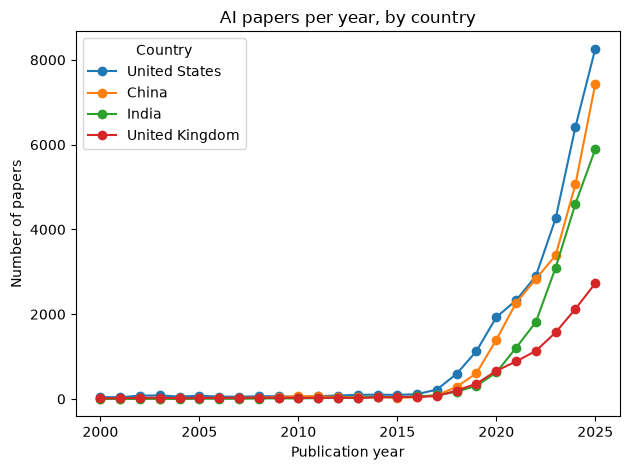

In [202]:
q5_wide.plot(kind="line", marker="o")
plt.title("AI papers per year, by country")
plt.xlabel("Publication year")
plt.ylabel("Number of papers")
plt.legend(title="Country")
plt.tight_layout()
plt.savefig("results/fig2_country_trends.png", dpi=200)
plt.show()

**New insights.**

The United States leads in AI papers per year for most of this time period, while China briefly moves ahead around 2010 and nearly catches up again by 2025. Counts for all four countries rise sharply after 2020. India’s growth is especially noticeable: it moves from very few papers in the early years to third place by 2025, ahead of the United Kingdom.